# QA 베이스라인 — 3조건 비교 (closed_book / full_context / chunked_sequential)

QA 모델로 `eval_sample01.csv`를 3가지 조건에서 풀게 하고 유형별 정확도, 정답
근거 위치별 정확도, 조건별 효율성(API 호출 수·소요시간·토큰 사용량)을 비교한다.

- **A. closed_book** — 원문 없이 질문+선지만
- **B. full_context** — 원문 전체 제공
- **C. chunked_sequential** — 청크를 하나씩 순차 탐색, 최대 4개까지, 확신하면 조기 종료

In [92]:
import os
import random
import re
import sys
import threading
import time
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

from src.notebook_setup import setup_project

setup_project()
API_KEY_SET = bool(os.environ.get("NVIDIA_NIM_API_KEY"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yaml
from tqdm.auto import tqdm

plt.rcParams["font.family"] = "AppleGothic"  # 차트 한글 라벨 깨짐 방지 (macOS 기본 한글 폰트)
plt.rcParams["axes.unicode_minus"] = False


project root: /Users/lucyroh/Desktop/STUDY/Data Projects/rehearse-then-recall
.env 로드: 성공 ✅
NVIDIA_NIM_API_KEY: 설정됨 ✅


## 1. 데이터 로드

질문/정답 CSV(`utf-8-sig`)를 읽어 합치고, 원문(`sample01.txt`)을 `raw_text`로
저장한다.

In [93]:
questions_df = pd.read_csv("data/sample/eval_sample01.csv", encoding="utf-8-sig")
answers_df = pd.read_csv("data/sample/eval_sample01_ans.csv", encoding="utf-8-sig")

assert len(questions_df) == len(answers_df), "질문/정답 CSV 행 수가 다릅니다 — 1:1 대응이 깨짐"

df = pd.concat([questions_df, answers_df], axis=1)
df.insert(0, "문항번호", range(1, len(df) + 1))

with open("data/sample/sample01.txt", encoding="utf-8") as f:
    raw_text = f.read()

print(f"문항 수: {len(df)}")
print(f"원문: {len(raw_text)}자, {len(raw_text.split())}어절")
df.head()


문항 수: 120
원문: 34267자, 8457어절


,문항번호,문제,선지1,선지2,선지3,선지4,정답,정답_근거_위치(어절 번호),근거_최소어절,근거_최대어절,근거_어절_범위,유형
0,1,해성 아파트 102동 노인이 만든 구조물은 몇 개인가?,두 개,세 개,네 개,다섯 개,3,20-24,20,24,4,단일 장면 사실 확인형
1,2,노인이 만든 구조물 네 개의 이름에 포함되지 않는 것은?,큐브,망루,캣 타워,물레방아,4,28-32,28,32,4,부정형 사실 확인형
2,3,윤재가 어제 구해온 것은?,플라스틱 의자,베이지색 패브릭 소파,사무용 회전의자,나무 벤치,2,101-103,101,103,2,단일 장면 사실 확인형
3,4,패브릭 소파는 노인에게 몇 번째로 선택받지 못한 물건인가?,두번째,세번째,네번째,다섯번째,3,146-151,146,151,5,단일 장면 사실 확인형
4,5,윤재가 오늘 핑계를 대야 할 상대는 누구인가?,장 주무관,콜라 작가,지도 교수,102동 노인,1,167-173,167,173,6,단일 장면 사실 확인형


## 2. 청크 생성 (조건 C용)

`paginate_semantic`으로 원문을 청크로 나눈다. 한 번만 만들어 모든 조건·문항에서
재사용한다.

In [94]:
if not API_KEY_SET:
    print("NVIDIA_NIM_API_KEY가 없어 청크 생성을 건너뜁니다 — 이후 셀들도 이어서 실행할 수 없습니다.")
else:
    from src.pipeline.chuncking import paginate_semantic, plain_text_to_paragraphs
    from src.pipeline.embeddings import embed_texts, load_config

    paragraphs = plain_text_to_paragraphs(raw_text)
    chunk_cfg = yaml.safe_load(open("configs/chunking.yaml", encoding="utf-8"))
    embed_cfg = load_config("configs/importance_filter.yaml")

    chunks_real = paginate_semantic(
        paragraphs,
        min_words=chunk_cfg["min_words"],
        max_words=chunk_cfg["max_words"],
        granularity="paragraph",
        config=embed_cfg,
        embed_fn=embed_texts,
    )
    print(f"청크 수: {len(chunks_real)}")


청크 수: 37


## 3. NIM 채팅 API 호출 (`call_chat`)

`meta/llama-3.1-8b-instruct`로 NIM 채팅 API를 호출한다. 레이트 리미터(`RateLimiter`,
분당 30회)로 실제 호출 속도를 제한하고, 타임아웃·5xx 오류는 지수 백오프로 최대
3회 재시도한다. 응답의 토큰 사용량은 `last_chat_usage()`로 조회한다(스레드별로
격리되어 병렬 실행 시 서로 안 섞임).

In [95]:
QA_MODEL = "meta/llama-3.1-8b-instruct"
QA_API_KEY = os.environ.get("NVIDIA_NIM_API_KEY")
_CHAT_API_URL = "https://integrate.api.nvidia.com/v1/chat/completions"
_RETRYABLE_STATUS = {429, 500, 502, 503, 504}

_usage_local = threading.local()


def last_chat_usage() -> dict | None:
    """현재 스레드에서 가장 최근 call_chat 성공 호출의 토큰 사용량
    ({prompt_tokens, completion_tokens, total_tokens}). embeddings.last_embedding_error()와
    같은 전역 상태 조회 패턴이되, 병렬 호출(6번) 때문에 스레드별로 격리했다.
    """
    return getattr(_usage_local, "value", None)


class RateLimiter:
    """분당 최대 호출 수를 강제하는 슬라이딩 윈도우 레이트 리미터.

    여러 스레드가 동시에 acquire()를 부르는 걸 전제로 만들었다 — 락은 최근
    60초 안의 호출 타임스탬프를 확인/기록하는 짧은 구간에서만 잡고, 대기는
    락 밖에서 한다(다른 스레드를 막지 않기 위함). MAX_WORKERS를 아무리 늘려도
    실제 초당/분당 호출 속도는 이 리미터가 최종적으로 결정한다.
    """

    def __init__(self, max_per_minute: int):
        self.max_per_minute = max_per_minute
        self._lock = threading.Lock()
        self._timestamps: deque = deque()

    def acquire(self) -> None:
        while True:
            with self._lock:
                now = time.time()
                while self._timestamps and now - self._timestamps[0] > 60:
                    self._timestamps.popleft()
                if len(self._timestamps) < self.max_per_minute:
                    self._timestamps.append(now)
                    return
                sleep_for = 60 - (now - self._timestamps[0]) + 0.05
            time.sleep(sleep_for)


# NIM 무료 티어 RPM(~40/분)보다 여유 있게 잡음 — 429가 그래도 뜨면 더 낮출 것
_rate_limiter = RateLimiter(max_per_minute=30)


class ChatAPIError(RuntimeError):
    """embeddings.EmbeddingAPIError와 같은 패턴 — NIM 채팅 API 호출 실패."""


def _backoff_seconds(attempt: int) -> float:
    """지수 백오프 + 지터. attempt=0,1,2,... -> 대략 2,4,8...초(최대 20초) + 0~1초 지터.
    고정 3초 대기로는 NIM이 잠깐 과부하(503)일 때 재시도 3번이 몇 초 안에 다
    소진돼버려 못 버틴다 — 뒤로 갈수록 더 오래 기다려야 회복 시간을 벌 수 있다.
    """
    return min(2.0 * (2**attempt), 20.0) + random.uniform(0, 1.0)


def call_chat(
    messages: list[dict],
    model: str,
    api_key: str,
    temperature: float = 0.0,
    timeout: float = 120.0,
    max_retries: int = 3,
) -> str:
    """NIM 채팅 API(OpenAI 호환 메시지 형식)를 호출해 응답 텍스트를 반환한다.

    실제 HTTP 요청 직전마다(최초 시도든 재시도든) _rate_limiter.acquire()를
    거쳐 분당 호출 수를 강제한다 — 429는 여기서 예방하는 게 우선이고,
    타임아웃/연결 오류/일시적 서버 오류(429, 5xx)에 대한 재시도(최대
    max_retries회, 지수 백오프)는 그래도 남는 경우를 위한 이중 안전장치다.
    chunked_sequential(run_chunked_sequential)은 문항 하나당 최대 4번 호출해서
    실패에 노출될 기회가 A/B보다 많으므로 재시도를 좀 더 넉넉히 잡았다.
    성공하면 응답의 usage를 last_chat_usage()로 조회할 수 있게 저장해둔다
    (호출한 스레드 로컬에 저장 — 병렬 실행 시 스레드끼리 안 섞임).
    """
    last_error: Exception | None = None
    for attempt in range(max_retries + 1):
        _rate_limiter.acquire()
        try:
            response = requests.post(
                _CHAT_API_URL,
                headers={"Authorization": f"Bearer {api_key}", "Accept": "application/json"},
                json={"model": model, "messages": messages, "temperature": temperature},
                timeout=timeout,
            )
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            last_error = e
            if attempt < max_retries:
                time.sleep(_backoff_seconds(attempt))
                continue
            raise ChatAPIError(f"NIM 채팅 API 호출 실패(재시도 {max_retries}회 소진): {type(e).__name__}: {e}") from e

        if response.status_code == 200:
            data = response.json()
            _usage_local.value = data.get("usage")
            return data["choices"][0]["message"]["content"]

        if response.status_code in _RETRYABLE_STATUS and attempt < max_retries:
            time.sleep(_backoff_seconds(attempt))
            continue
        raise ChatAPIError(f"NIM 채팅 API 실패 ({response.status_code}): {response.text}")

    raise ChatAPIError(f"NIM 채팅 API 호출 실패(재시도 소진): {last_error}")


if API_KEY_SET:
    test_reply = call_chat(
        [{"role": "user", "content": "숫자 1만 출력하세요."}],
        model=QA_MODEL,
        api_key=QA_API_KEY,
    )
    print("동작 확인:", test_reply, "| usage:", last_chat_usage())


동작 확인: 1 | usage: {'prompt_tokens': 43, 'completion_tokens': 2, 'total_tokens': 45, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 16}}


## 4. 메시지 빌더 — 3가지 조건

세 조건 모두 질문+선지 문구(`_question_turn`)를 공유하고, system 메시지 맨
앞에 검색 금지 문구를 붙인다.

- **A. closed_book** — 질문+선지만. API 호출 1번.
- **B. full_context** — 원문 전체 제공. API 호출 1번.
- **C. chunked_sequential** — 청크를 하나씩 실제로 보여주며 매번 API 호출,
  확신하면 조기 종료, 최대 4개까지. 문항마다 API 호출 1~4번(`run_chunked_sequential`이
  사용한 청크 수·소요시간·토큰을 반환 — 분석 C의 재료).

In [96]:
_NO_TOOLS_SENTENCE = (
    "웹 검색이나 외부 도구를 쓰지 말고, 오직 주어진 정보(또는 당신이 원래 알고 있는 지식)만으로 답하세요."
)
_ANSWER_INSTRUCTION = "반드시 1,2,3,4 중 정답 번호 하나만 출력하세요. 다른 설명은 쓰지 마세요."
_CONTINUE_SIGNAL = "계속"
MAX_CHUNKS_EXPLORE = 4


def _question_turn(row: pd.Series) -> dict:
    """질문+선지 문구 — 조건과 무관하게 항상 동일한 템플릿."""
    content = (
        f"{_ANSWER_INSTRUCTION}\n\n"
        f"문제: {row['문제']}\n"
        f"1) {row['선지1']}\n"
        f"2) {row['선지2']}\n"
        f"3) {row['선지3']}\n"
        f"4) {row['선지4']}"
    )
    return {"role": "user", "content": content}


def build_messages_closedbook(row: pd.Series) -> list[dict]:
    """A. closed_book — 원문 없이 질문+선지만."""
    system = {"role": "system", "content": f"{_NO_TOOLS_SENTENCE} 당신은 소설 독해 문제를 푸는 도우미입니다."}
    return [system, _question_turn(row)]


def build_messages_fullcontext(row: pd.Series, raw_text: str) -> list[dict]:
    """B. full_context — 원문 전체를 하나의 블록으로 통째로 제공."""
    system = {"role": "system", "content": f"{_NO_TOOLS_SENTENCE} 당신은 소설 독해 문제를 푸는 도우미입니다."}
    context = {
        "role": "user",
        "content": f"다음 글을 읽고 이어지는 질문에 답하세요.\n\n{raw_text}",
    }
    return [system, context, _question_turn(row)]


def run_chunked_sequential(row: pd.Series, chunks: list, model: str, api_key: str) -> dict:
    """C. chunked_sequential (실제 반복 탐색).

    청크를 한 번에 하나씩 실제로 보여주고, 모델이 그 시점에서 답할 수 있다고
    판단하면(1~4 중 번호 출력) 조기 종료한다. 최대 MAX_CHUNKS_EXPLORE개까지만
    탐색 가능 — 그 안에 못 찾으면 마지막 청크에서 강제로 답하게 한다. 질문을
    청크보다 먼저 알려주는 이유는, 모델이 각 청크를 "이 정보가 답에 쓸모 있는가"
    기준으로 판단하려면 질문을 미리 알아야 하기 때문이다(이전 버전은 질문을 맨
    마지막에만 줬는데, 그건 전체를 다 읽고 나서 답하는 구조라 가능했던 것).

    청크 단계마다 실제 API 호출이 일어나므로(최대 4회) A/B(항상 1회)와 비교해
    API 호출 수·소요시간·토큰 사용량이 달라진다 — 반환값에 전부 담아 효율성
    비교에 쓴다.
    """
    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} 당신은 소설 독해 문제를 푸는 도우미입니다. "
            f"질문에 답하기 위해 원문을 청크 단위로 한 번에 하나씩 보여줄게요"
            f"(최대 {MAX_CHUNKS_EXPLORE}개). 각 청크를 본 뒤, 이미 답을 확신할 수 있으면 "
            f"1,2,3,4 중 정답 번호만 출력하고, 아직 확신이 없어 다음 청크를 더 봐야 한다면 "
            f"반드시 '{_CONTINUE_SIGNAL}'라고만 출력하세요."
        ),
    }
    messages = [system, _question_turn(row)]

    explore_chunks = chunks[:MAX_CHUNKS_EXPLORE]
    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    prediction = None
    chunks_used = 0

    for i, c in enumerate(explore_chunks):
        is_last = i == len(explore_chunks) - 1
        instruction = (
            "이게 마지막으로 보여줄 청크입니다 — 반드시 1,2,3,4 중 정답 번호 하나만 출력하세요."
            if is_last
            else f"이 정보로 답할 수 있으면 1,2,3,4 중 번호만, 아직 확신이 없으면 '{_CONTINUE_SIGNAL}'라고만 출력하세요."
        )
        messages.append(
            {"role": "user", "content": f"[청크 {i + 1}/{len(explore_chunks)}]\n{c.text}\n\n{instruction}"}
        )

        t0 = time.time()
        reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        chunks_used = i + 1

        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        messages.append({"role": "assistant", "content": reply})  # 실제 모델 응답 — 이전 버전과 달리 고정 문구 아님

        prediction = parse_answer(reply)
        if prediction is not None:
            break

    return {
        "모델예측": prediction,
        "API호출수": chunks_used,
        "소요시간": round(total_elapsed, 1),
        "프롬프트토큰": total_tokens["prompt_tokens"],
        "완성토큰": total_tokens["completion_tokens"],
        "총토큰": total_tokens["total_tokens"],
    }


## 5. 답 파싱

In [97]:
def parse_answer(text: str) -> int | None:
    """응답 텍스트에서 1~4 중 첫 숫자를 추출한다. 못 찾으면 None."""
    match = re.search(r"[1-4]", text)
    return int(match.group()) if match else None


## 6. 실험 루프 — 전체 문항 × 3조건 (문항 단위 병렬)

문항(row) 단위로 `ThreadPoolExecutor(max_workers=8)`를 이용해 병렬 처리한다.
완료 순서가 뒤섞이므로 문항번호로 정렬 후 저장한다. 체크포인트는 조건
단위로 재개된다(끝난 조건은 재호출 안 함). 실패한 문항은 `모델예측=None`으로
기록한다.

In [98]:
RESULTS_PATH = "results/qa_baseline_3conditions.csv"
CONDITIONS = ["closed_book", "full_context", "chunked_sequential"]
MAX_WORKERS = 8  # NIM 무료 티어 RPM(~40/분) 기준 보수적으로 설정 — 429 잦으면 낮추고, 여유 있으면 올릴 것


def _run_single_call_condition(row: pd.Series, condition: str) -> dict:
    """A/B — API 호출 1번. C와 반환 스키마를 맞추기 위해 API호출수=1, 토큰은
    last_chat_usage()에서 그대로 가져온다."""
    if condition == "closed_book":
        messages = build_messages_closedbook(row)
    else:
        messages = build_messages_fullcontext(row, raw_text)

    t0 = time.time()
    reply = call_chat(messages, model=QA_MODEL, api_key=QA_API_KEY, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    return {
        "모델예측": parse_answer(reply),
        "API호출수": 1,
        "소요시간": round(elapsed, 1),
        "프롬프트토큰": usage.get("prompt_tokens") or 0,
        "완성토큰": usage.get("completion_tokens") or 0,
        "총토큰": usage.get("total_tokens") or 0,
    }


def _run_one_question(condition: str, row: pd.Series) -> dict:
    """문항 하나를 조건 하나에 대해 끝까지 처리 — 스레드 풀의 작업 단위.
    chunked_sequential은 함수 내부(청크 1→2→3→4)는 순차지만, 문항끼리는 병렬로
    돌아간다(이 함수 자체가 여러 스레드에서 동시에 호출됨).
    """
    try:
        if condition == "chunked_sequential":
            outcome = run_chunked_sequential(row, chunks_real, QA_MODEL, QA_API_KEY)
        else:
            outcome = _run_single_call_condition(row, condition)
    except Exception as e:
        outcome = {
            "모델예측": None,
            "API호출수": None,
            "소요시간": None,
            "프롬프트토큰": None,
            "완성토큰": None,
            "총토큰": None,
        }
        # tqdm.write는 스레드에서 직접 불러도 안전(tqdm 내부 락 사용) — 진행바를
        # 안 깨고 실패 내역을 남길 수 있다.
        tqdm.write(f"  [{condition}] 문항 {row['문항번호']} 실패: {type(e).__name__}: {e}")

    return {
        "문항번호": row["문항번호"],
        "조건": condition,
        "정답": row["정답"],
        "정답여부": outcome["모델예측"] == row["정답"],
        "유형": row["유형"],
        "근거_최소어절": row["근거_최소어절"],
        **outcome,
    }


if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH, encoding="utf-8-sig")
    print(f"기존 체크포인트를 불러왔습니다: {RESULTS_PATH} ({len(existing_df)}행)")
else:
    existing_df = pd.DataFrame()

done_conditions = set(existing_df["조건"].unique()) if len(existing_df) else set()
remaining_conditions = [c for c in CONDITIONS if c not in done_conditions]

if not remaining_conditions:
    print("모든 조건이 이미 체크포인트에 있습니다 — API 재호출 없이 그대로 씁니다.")
    results_df = existing_df
elif not API_KEY_SET:
    print("NVIDIA_NIM_API_KEY가 없어 남은 조건을 건너뜁니다:", remaining_conditions)
    results_df = existing_df
else:
    if done_conditions:
        print(f"이미 끝난 조건: {sorted(done_conditions)} — 재호출 없이 유지")
        print(f"이번에 돌릴 조건: {remaining_conditions}")
    results = existing_df.to_dict("records")
    for condition in remaining_conditions:
        condition_results = []
        pbar = tqdm(total=len(df), desc=condition)
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            futures = [executor.submit(_run_one_question, condition, row) for _, row in df.iterrows()]
            for future in as_completed(futures):
                result = future.result()
                condition_results.append(result)
                pbar.set_postfix(예측=result["모델예측"], 호출=result["API호출수"])
                pbar.update(1)
        pbar.close()

        # 병렬 실행이라 완료 순서가 뒤섞여 있으니, 저장 전에 문항번호로 정렬
        condition_results.sort(key=lambda r: r["문항번호"])
        results.extend(condition_results)

        results_df = pd.DataFrame(results)
        results_df.to_csv(RESULTS_PATH, index=False, encoding="utf-8-sig")
        print(f"[{condition}] 체크포인트 저장: {RESULTS_PATH} ({len(results_df)}행)")

    results_df = pd.DataFrame(results)

results_df.head()


기존 체크포인트를 불러왔습니다: results/qa_baseline_3conditions.csv (360행)
모든 조건이 이미 체크포인트에 있습니다 — API 재호출 없이 그대로 씁니다.


,문항번호,조건,정답,정답여부,유형,근거_최소어절,모델예측,API호출수,소요시간,프롬프트토큰,완성토큰,총토큰
0,1,closed_book,3,False,단일 장면 사실 확인형,20,2.0,1.0,0.5,155.0,5.0,160.0
1,2,closed_book,4,False,부정형 사실 확인형,28,3.0,1.0,0.5,156.0,7.0,163.0
2,3,closed_book,2,True,단일 장면 사실 확인형,101,2.0,1.0,0.4,162.0,3.0,165.0
3,4,closed_book,3,False,단일 장면 사실 확인형,146,1.0,1.0,0.5,158.0,5.0,163.0
4,5,closed_book,1,False,단일 장면 사실 확인형,167,3.0,1.0,0.5,158.0,5.0,163.0


## 7. 분석 A — 유형별 정확도

In [99]:
type_accuracy = results_df.pivot_table(
    index="유형", columns="조건", values="정답여부", aggfunc="mean"
)
type_accuracy = type_accuracy[CONDITIONS]  # 열 순서를 A/B/C 순으로 고정
type_accuracy


조건,closed_book,full_context,chunked_sequential
유형,,,
단일 장면 사실 확인형,0.483051,0.898305,0.389831
부정형 사실 확인형,0.500000,0.000000,0.000000


## 8. 분석 B — 정답 근거 위치별 정확도 히스토그램

`근거_최소어절`을 500어절 단위로 나눠 조건별 정확도를 막대그래프로 비교한다.
우연 수준(25%) 기준선 포함.

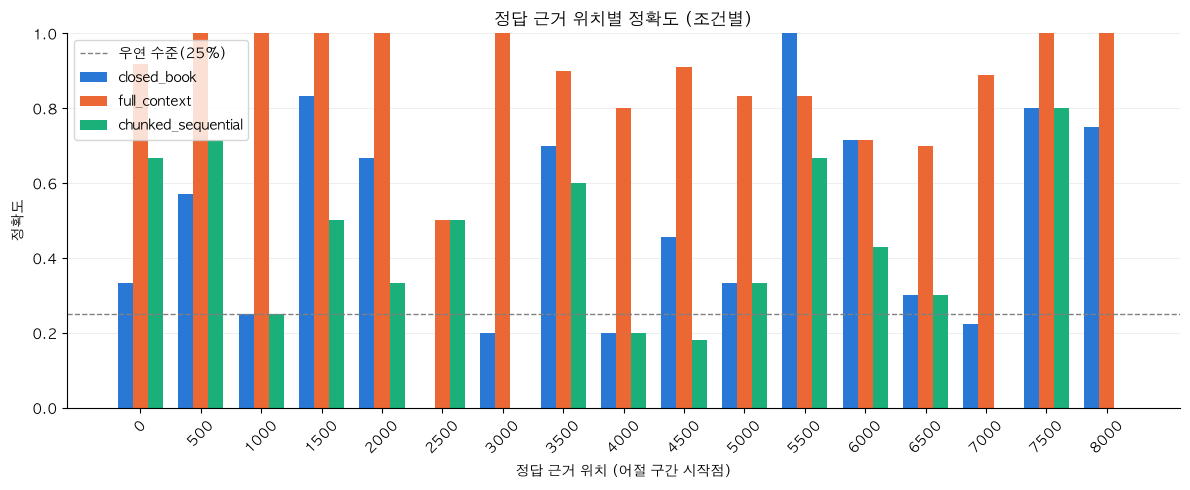

In [100]:
total_words = len(raw_text.split())
bins = list(range(0, total_words + 500, 500))
results_df["어절_구간"] = pd.cut(results_df["근거_최소어절"], bins=bins, right=False)

position_accuracy = results_df.pivot_table(
    index="어절_구간", columns="조건", values="정답여부", aggfunc="mean", observed=False
)
position_accuracy = position_accuracy[CONDITIONS]

# 카테고리(조건) 3개 — 색맹 안전성이 검증된 categorical 팔레트의 앞 3개 슬롯
CONDITION_COLORS = {
    "closed_book": "#2a78d6",  # blue
    "full_context": "#eb6834",  # orange
    "chunked_sequential": "#1baf7a",  # aqua
}

bin_labels = [str(interval.left) for interval in position_accuracy.index]
x = np.arange(len(position_accuracy))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, condition in enumerate(CONDITIONS):
    ax.bar(
        x + i * bar_width,
        position_accuracy[condition],
        width=bar_width,
        label=condition,
        color=CONDITION_COLORS[condition],
    )

ax.axhline(0.25, linestyle="--", color="gray", linewidth=1, label="우연 수준(25%)")
ax.set_xticks(x + bar_width)
ax.set_xticklabels(bin_labels, rotation=45)
ax.set_xlabel("정답 근거 위치 (어절 구간 시작점)")
ax.set_ylabel("정확도")
ax.set_title("정답 근거 위치별 정확도 (조건별)")
ax.set_ylim(0, 1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)
ax.legend()
plt.tight_layout()
plt.show()


## 9. 분석 B-2 — 정답 근거 상대 위치(%)별 정확도 히스토그램

근거 위치를 원문 길이 대비 %로 환산해 10구간으로 조건별 정확도를 비교한다
(원문 길이가 달라져도 비교 가능).

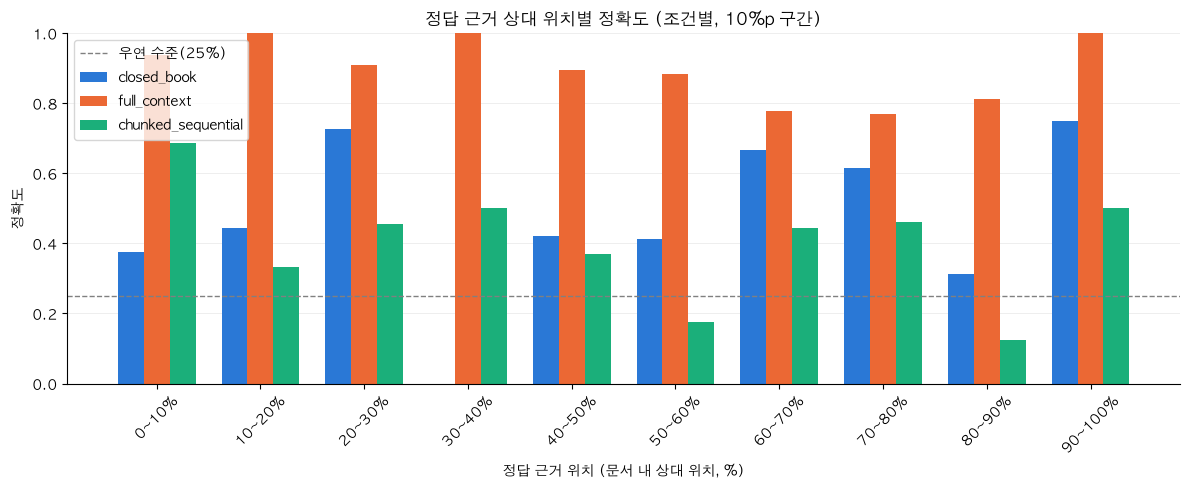

In [101]:
results_df["위치_퍼센트"] = results_df["근거_최소어절"] / total_words * 100

pct_bin_edges = list(range(0, 100, 10)) + [100]
pct_bin_labels = [f"{pct_bin_edges[i]}~{pct_bin_edges[i + 1]}%" for i in range(len(pct_bin_edges) - 1)]
pct_cut_edges = pct_bin_edges[:-1] + [100.001]  # 정확히 100%인 값도 마지막 구간에 포함되게
results_df["퍼센트_구간"] = pd.cut(
    results_df["위치_퍼센트"], bins=pct_cut_edges, right=False, labels=pct_bin_labels
)

pct_accuracy = results_df.pivot_table(
    index="퍼센트_구간", columns="조건", values="정답여부", aggfunc="mean", observed=False
)
pct_accuracy = pct_accuracy[CONDITIONS]

x = np.arange(len(pct_accuracy))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, condition in enumerate(CONDITIONS):
    ax.bar(
        x + i * bar_width,
        pct_accuracy[condition],
        width=bar_width,
        label=condition,
        color=CONDITION_COLORS[condition],
    )

ax.axhline(0.25, linestyle="--", color="gray", linewidth=1, label="우연 수준(25%)")
ax.set_xticks(x + bar_width)
ax.set_xticklabels(pct_accuracy.index.astype(str), rotation=45)
ax.set_xlabel("정답 근거 위치 (문서 내 상대 위치, %)")
ax.set_ylabel("정확도")
ax.set_title("정답 근거 상대 위치별 정확도 (조건별, 10%p 구간)")
ax.set_ylim(0, 1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)
ax.legend()
plt.tight_layout()
plt.show()


## 10. 분석 C — 조건별 효율성 비교 (API 호출 수·소요시간·토큰 사용량)

조건별 평균 정확도·API 호출 수·소요시간·토큰 사용량을 표와 막대그래프로
비교한다.

In [102]:
efficiency = results_df.groupby("조건").agg(
    정확도=("정답여부", "mean"),
    평균_API호출수=("API호출수", "mean"),
    평균_소요시간_초=("소요시간", "mean"),
    평균_프롬프트토큰=("프롬프트토큰", "mean"),
    평균_완성토큰=("완성토큰", "mean"),
    평균_총토큰=("총토큰", "mean"),
)
efficiency = efficiency.reindex(CONDITIONS)
efficiency


,정확도,평균_API호출수,평균_소요시간_초,평균_프롬프트토큰,평균_완성토큰,평균_총토큰
조건,,,,,,
closed_book,0.483333,1.000000,12.604167,168.491667,5.691667,174.183333
full_context,0.883333,1.000000,14.806897,22119.241379,6.534483,22125.775862
chunked_sequential,0.383333,3.091667,80.940833,4948.725000,8.275000,4957.000000


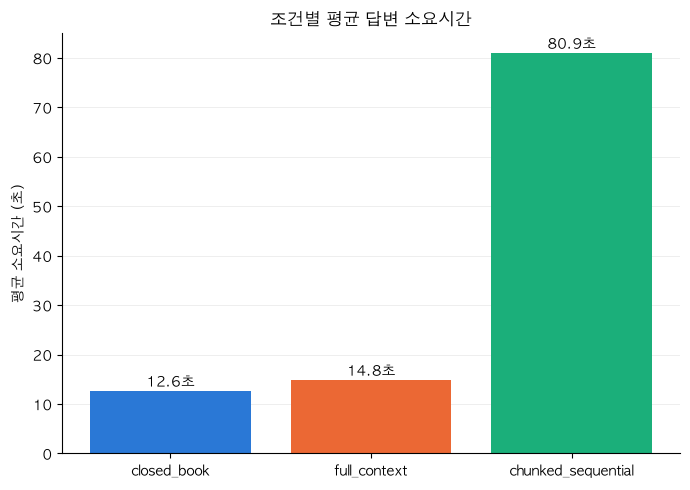

In [103]:
fig, ax = plt.subplots(figsize=(7, 5))
avg_time = efficiency["평균_소요시간_초"]
ax.bar(CONDITIONS, avg_time, color=[CONDITION_COLORS[c] for c in CONDITIONS])
ax.set_ylabel("평균 소요시간 (초)")
ax.set_title("조건별 평균 답변 소요시간")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)
for i, v in enumerate(avg_time):
    ax.text(i, v, f"{v:.1f}초", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 해석

**전체 정확도**: full_context 88.3% > closed_book 48.3% > chunked_sequential 38.3%

- **closed_book이 48.3%로 우연 수준(25%)보다 훨씬 높다.** 질문·선지 자체에
  단서가 있거나 모델이 상식으로 어느 정도 맞힌다는 뜻 — "원문 없이는 못
  맞혀야 정상"이라는 가정은 이번 데이터에서는 성립하지 않았다.
- **chunked_sequential(38.3%)이 closed_book(48.3%)보다도 낮다** — "정보를
  조금 준 것"이 "아예 안 준 것"보다 나쁘다는, 직관에 반하는 결과다. 원인은
  위치별 정확도로 확인된다: 근거가 청크 예산(최대 4개, 문서의 약 16.6%) 안에
  있는 문항은 정확도 63.6%인데, 예산 밖이면 32.7%로 떨어진다(closed_book보다
  낮음) — 일부만 읽은 무관한 내용이 모델을 오답으로 끌고 가는 것으로 보인다.
- **효율성도 chunked_sequential이 진다.** 평균 81초·4,957토큰 vs full_context
  15초·22,126토큰. 이 문서 크기(8,457단어)·이 모델(8B)에서는 굳이 예산을
  나눌 이유가 없었다 — 전체를 한 번에 읽는 쪽이 정확도·속도 둘 다 이겼다.
- ⚠️ "부정형 사실 확인형" 유형의 정확도(0%)는 **문항이 2개뿐이라 통계적으로
  무의미하다** — 표본이 늘어나기 전엔 해석하지 말 것.

**다음에 해볼 것**: `MAX_CHUNKS_EXPLORE`를 늘려(예: 8) 예산 부족이 진짜
원인인지 재확인하거나, 순서대로가 아니라 관련도 순으로 청크를 골라 보여주는
방식(RAG형 재정렬)과 비교.